In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,classification_report, confusion_matrix , roc_auc_score
import joblib


In [2]:
data = pd.read_csv("pneumonia_dataset.csv")
data

,PatientID,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,Oxygen_saturation,Crackles,Xray,WBC_count,Sputum_color,Temperature,Diagnosis
0,PNEU4091,M,3,Bloody,High,Mild,Mild,NaN,No,92,Yes,-,-,-,39.7,Yes
1,PNEU6231,M,3,Dry,NaN,NaN,NaN,Mild,-,-,Yes,-,-,Clear,37.0,No
2,PNEU6486,M,3,Dry,NaN,NaN,NaN,Mild,No,99,No,-,-,-,38.0,No
3,PNEU7601,F,3,NaN,Low,Severe,NaN,Moderate,No,99,Yes,-,-,Clear,40.9,Yes
4,PNEU8471,F,3,NaN,High,Moderate,Severe,Mild,-,91,No,-,-,Green,38.1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705,PNEU360,F,90,Wet,NaN,Moderate,Moderate,Moderate,No,99,Yes,-,-,Green,38.3,Yes
706,PNEU4391,F,90,Dry,High,Moderate,Moderate,Moderate,Yes,91,Yes,-,-,Bloody,37.2,Yes
707,PNEU6720,M,90,Dry,NaN,NaN,NaN,Mild,No,90,Yes,-,-,-,37.0,No
708,PNEU9254,M,90,NaN,Moderate,Severe,Severe,Moderate,No,93,Yes,-,-,Bloody,36.2,Yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            710 non-null    object 
 1   Gender               710 non-null    object 
 2   Age                  710 non-null    int64  
 3   Cough                398 non-null    object 
 4   Fever                400 non-null    object 
 5   Shortness_of_breath  393 non-null    object 
 6   Chest_pain           367 non-null    object 
 7   Fatigue              605 non-null    object 
 8   Confusion            710 non-null    object 
 9   Oxygen_saturation    710 non-null    object 
 10  Crackles             710 non-null    object 
 11  Xray                 710 non-null    object 
 12  WBC_count            710 non-null    object 
 13  Sputum_color         710 non-null    object 
 14  Temperature          710 non-null    float64
 15  Diagnosis            710 non-null    obj

In [4]:
data["Xray"].value_counts()

Xray
-                      700
Patchy infiltrates       4
Normal                   3
Diffuse infiltrates      2
Lobar consolidation      1
Name: count, dtype: int64

In [5]:
data["WBC_count"].value_counts()

WBC_count
-        700
9803       1
9672       1
9800       1
10233      1
11513      1
7213       1
5322       1
10897      1
9944       1
9544       1
Name: count, dtype: int64

In [6]:
data = data.drop(["Xray","WBC_count", "PatientID","Sputum_color"], axis=1)
data = data.replace("-", pd.NA)

numeric_cols = ["Oxygen_saturation", "Age", "Temperature"]
for col in numeric_cols:
	data[col] = pd.to_numeric(data[col])

data = data.fillna(data.median(numeric_only=True))
data = data.fillna(data.mode().iloc[0])
data


,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,Oxygen_saturation,Crackles,Temperature,Diagnosis
0,M,3,Bloody,High,Mild,Mild,Mild,No,92.0,Yes,39.7,Yes
1,M,3,Dry,Low,Mild,Mild,Mild,No,93.0,Yes,37.0,No
2,M,3,Dry,Low,Mild,Mild,Mild,No,99.0,No,38.0,No
3,F,3,Dry,Low,Severe,Mild,Moderate,No,99.0,Yes,40.9,Yes
4,F,3,Dry,High,Moderate,Severe,Mild,No,91.0,No,38.1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
705,F,90,Wet,Low,Moderate,Moderate,Moderate,No,99.0,Yes,38.3,Yes
706,F,90,Dry,High,Moderate,Moderate,Moderate,Yes,91.0,Yes,37.2,Yes
707,M,90,Dry,Low,Mild,Mild,Mild,No,90.0,Yes,37.0,No
708,M,90,Dry,Moderate,Severe,Severe,Moderate,No,93.0,Yes,36.2,Yes


In [7]:
data["Diagnosis"].value_counts()

Diagnosis
Yes    408
No     302
Name: count, dtype: int64

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               710 non-null    object 
 1   Age                  710 non-null    int64  
 2   Cough                710 non-null    object 
 3   Fever                710 non-null    object 
 4   Shortness_of_breath  710 non-null    object 
 5   Chest_pain           710 non-null    object 
 6   Fatigue              710 non-null    object 
 7   Confusion            710 non-null    object 
 8   Oxygen_saturation    710 non-null    float64
 9   Crackles             710 non-null    object 
 10  Temperature          710 non-null    float64
 11  Diagnosis            710 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 66.7+ KB


In [9]:
binary_cols = []
multi_cols = []
for col in data.columns:
	if col == "Diagnosis":
		continue
	if len(data[col].unique()) == 2:
		binary_cols.append(col)
	else:
		multi_cols.append(col)

In [10]:
label_encoders = {}
for col in binary_cols:
	le = LabelEncoder()
	data[col] = le.fit_transform(data[col])
	label_encoders[col] = le
categorical_cols = [c for c in multi_cols if c not in numeric_cols]
data

,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,Oxygen_saturation,Crackles,Temperature,Diagnosis
0,1,3,Bloody,High,Mild,Mild,Mild,0,92.0,1,39.7,Yes
1,1,3,Dry,Low,Mild,Mild,Mild,0,93.0,1,37.0,No
2,1,3,Dry,Low,Mild,Mild,Mild,0,99.0,0,38.0,No
3,0,3,Dry,Low,Severe,Mild,Moderate,0,99.0,1,40.9,Yes
4,0,3,Dry,High,Moderate,Severe,Mild,0,91.0,0,38.1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
705,0,90,Wet,Low,Moderate,Moderate,Moderate,0,99.0,1,38.3,Yes
706,0,90,Dry,High,Moderate,Moderate,Moderate,1,91.0,1,37.2,Yes
707,1,90,Dry,Low,Mild,Mild,Mild,0,90.0,1,37.0,No
708,1,90,Dry,Moderate,Severe,Severe,Moderate,0,93.0,1,36.2,Yes


In [11]:
OE = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoded = OE.fit_transform(data[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=OE.get_feature_names_out(categorical_cols))
data = data.drop(columns=categorical_cols)
data = pd.concat([data, encoded_df], axis=1)
data

,Gender,Age,Confusion,Oxygen_saturation,Crackles,Temperature,Diagnosis,Cough_Bloody,Cough_Dry,Cough_Wet,...,Fever_Moderate,Shortness_of_breath_Mild,Shortness_of_breath_Moderate,Shortness_of_breath_Severe,Chest_pain_Mild,Chest_pain_Moderate,Chest_pain_Severe,Fatigue_Mild,Fatigue_Moderate,Fatigue_Severe
0,1,3,0,92.0,1,39.7,Yes,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1,3,0,93.0,1,37.0,No,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1,3,0,99.0,0,38.0,No,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0,3,0,99.0,1,40.9,Yes,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0,3,0,91.0,0,38.1,Yes,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705,0,90,0,99.0,1,38.3,Yes,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
706,0,90,1,91.0,1,37.2,Yes,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
707,1,90,0,90.0,1,37.0,No,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
708,1,90,0,93.0,1,36.2,Yes,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [12]:
data["Diagnosis"] = LabelEncoder().fit_transform(data["Diagnosis"])
x = data.drop("Diagnosis", axis=1)
y = data["Diagnosis"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y)
y

0      1
1      0
2      0
3      1
4      1
      ..
705    1
706    1
707    0
708    1
709    0
Name: Diagnosis, Length: 710, dtype: int64

In [13]:
model = RandomForestClassifier(n_estimators=200 , max_depth=3 ,class_weight="balanced")
model.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
trained_encoders = {
	"label_encoders": label_encoders,
	"onehot_encoder": OE,
	"columns_order":x_train.columns
}
joblib.dump(model, "pneumonia_model.pkl")
joblib.dump(trained_encoders, "encoders.pkl")

['encoders.pkl']

In [15]:
y_predict = model.predict(x_test)
accuracy = accuracy_score(y_test , y_predict) * 100
print(f"Accuracy: {accuracy}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_predict))
print("\nClassification Report:")
print(classification_report(y_test, y_predict))

Accuracy: 96.47887323943662
Confusion Matrix:
[[60  0]
 [ 5 77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        60
           1       1.00      0.94      0.97        82

    accuracy                           0.96       142
   macro avg       0.96      0.97      0.96       142
weighted avg       0.97      0.96      0.96       142



In [16]:
y_train_pred = model.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred) * 100
test_accuracy = accuracy_score(y_test, y_predict) * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")

Training Accuracy: 98.42%
Testing Accuracy: 96.48%


In [17]:
y_prob = model.predict_proba(x_test)[:,1]
auc = roc_auc_score(y_test,y_prob)
print("AUC",auc)

AUC 0.9859756097560975


In [18]:
score = cross_val_score(model, x,y,cv=5,scoring='accuracy')
print(score)
print(f"Mean Score :{score}")

[0.96478873 0.97183099 0.95774648 0.98591549 0.97183099]
Mean Score :[0.96478873 0.97183099 0.95774648 0.98591549 0.97183099]


In [19]:
importance = model.feature_importances_
features = x.columns
fi = pd.Series(importance,index=features).sort_values(ascending=False)
fi

Cough_Dry                       1.838894e-01
Chest_pain_Mild                 1.698535e-01
Fatigue_Mild                    1.449752e-01
Fever_Low                       1.396564e-01
Shortness_of_breath_Mild        1.282261e-01
Cough_Wet                       2.910597e-02
Cough_Bloody                    2.710213e-02
Chest_pain_Severe               2.616775e-02
Fatigue_Severe                  2.314874e-02
Shortness_of_breath_Moderate    2.303883e-02
Chest_pain_Moderate             2.180210e-02
Temperature                     2.163857e-02
Fever_Moderate                  1.922112e-02
Fatigue_Moderate                1.452723e-02
Shortness_of_breath_Severe      1.329486e-02
Fever_High                      1.306245e-02
Oxygen_saturation               7.834558e-04
Crackles                        5.032623e-04
Age                             2.985082e-06
Gender                          8.795042e-18
Confusion                       2.362379e-18
dtype: float64

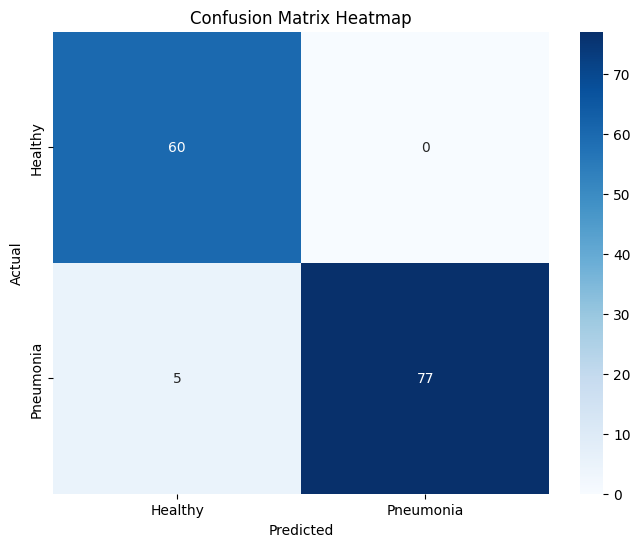

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Pneumonia'], yticklabels=['Healthy', 'Pneumonia'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Heatmap')
plt.show()

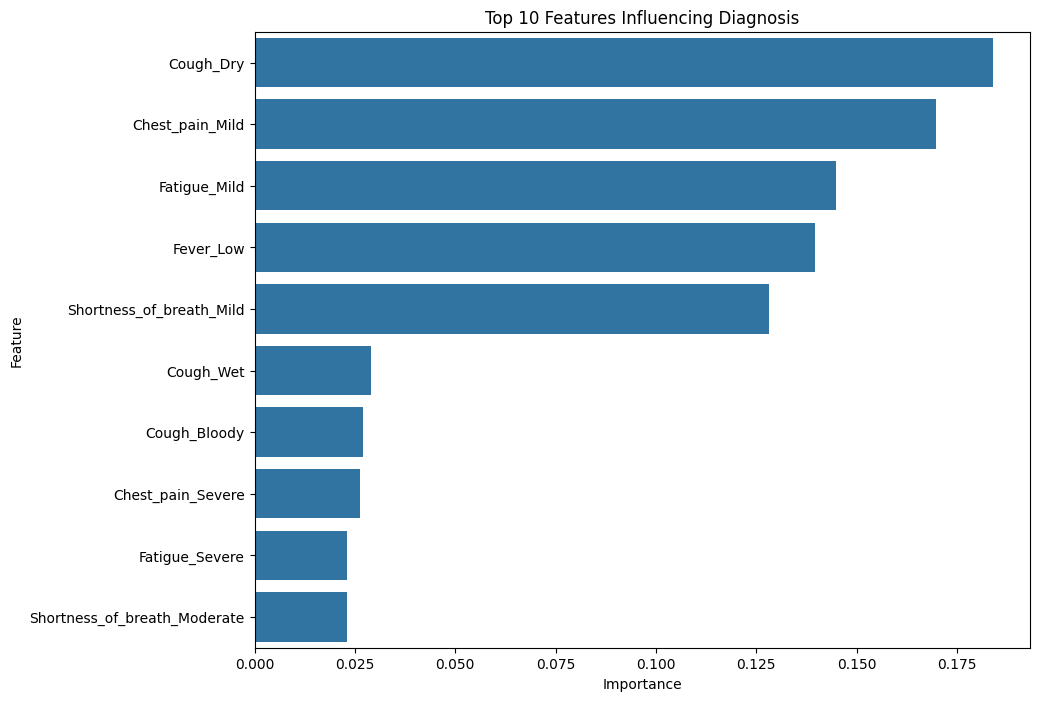

In [21]:
# استخراج أهمية الأعمدة
importances = model.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10)) # عرض أهم 10 فقط
plt.title('Top 10 Features Influencing Diagnosis')
plt.show()

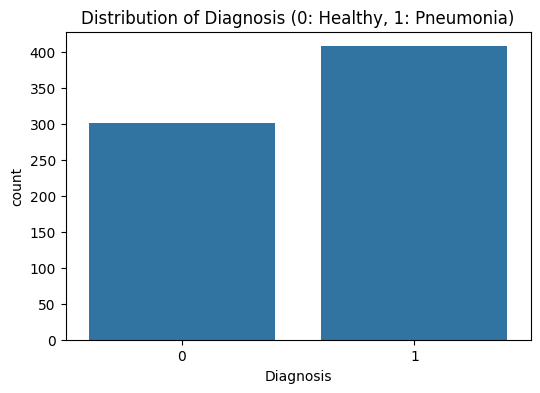

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x=data['Diagnosis'])
plt.title('Distribution of Diagnosis (0: Healthy, 1: Pneumonia)')
plt.show()

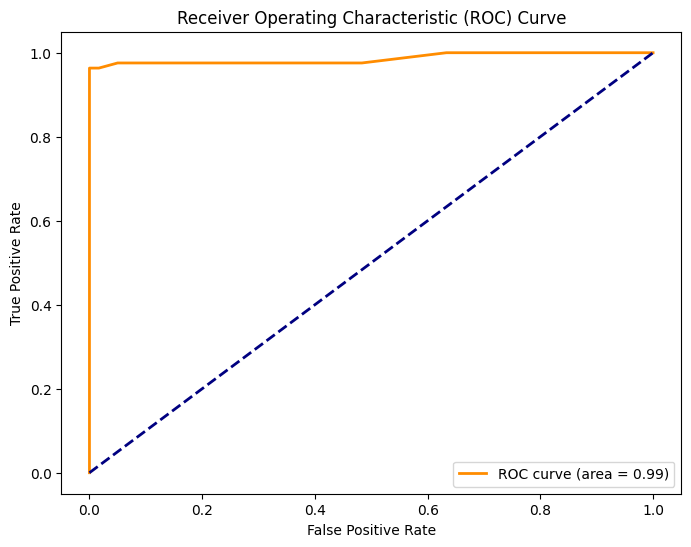

In [23]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

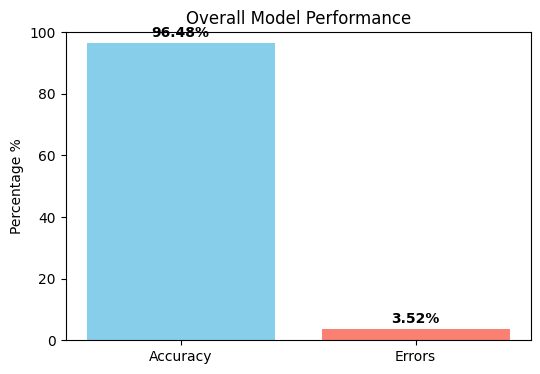

In [24]:
plt.figure(figsize=(6, 4))
metrics = ['Accuracy', 'Errors']
values = [accuracy, 100 - accuracy]
plt.bar(metrics, values, color=['skyblue', 'salmon'])
plt.ylim(0, 100)
plt.ylabel('Percentage %')
plt.title('Overall Model Performance')
for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

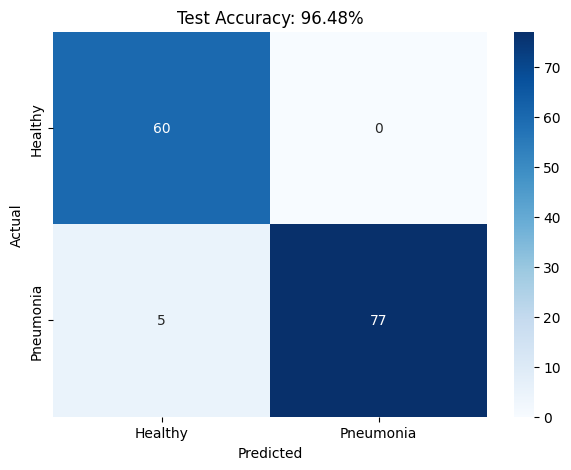

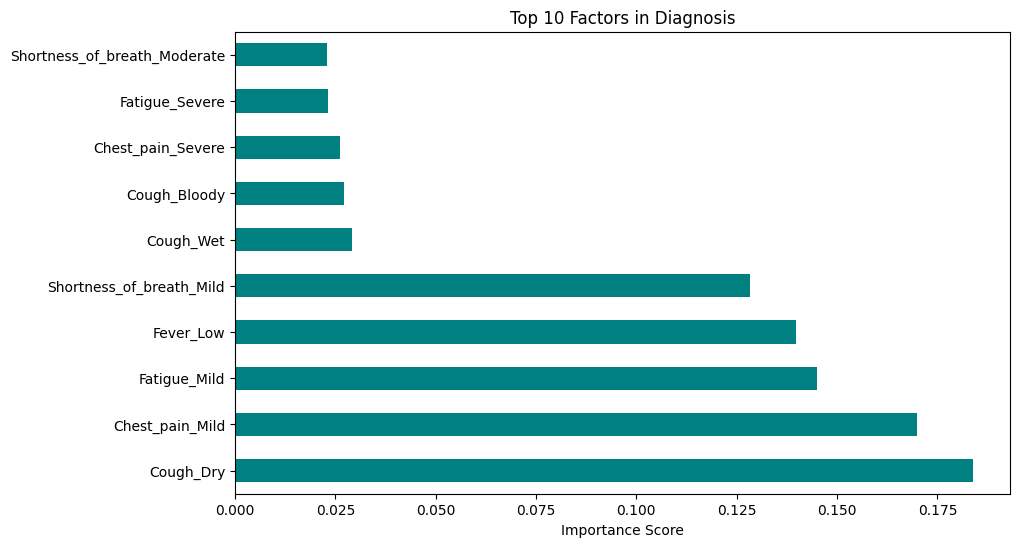

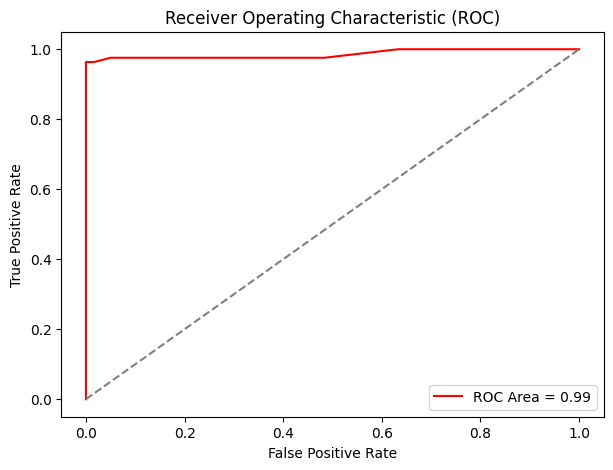

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. رسمة مصفوفة الارتباك (Confusion Matrix)
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Pneumonia'], yticklabels=['Healthy', 'Pneumonia'])
plt.title(f'Test Accuracy: {test_accuracy:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 2. رسمة أهمية الميزات (Feature Importance)
# هذه ستوضح للدكتور "لماذا" الموديل شاطر لهذه الدرجة
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=x.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Factors in Diagnosis')
plt.xlabel('Importance Score')
plt.show()

# 3. رسمة الـ ROC Curve (شهادة جودة الموديل)
y_probs = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='red', label=f'ROC Area = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()